In [27]:

from sqlalchemy import create_engine
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cybersecurity_attacks.csv")


In [28]:
df.describe()

,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


In [29]:
df.isnull().sum()

Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Payload Data                  0
Malware Indicators        20000
Anomaly Scores                0
Alerts/Warnings           20067
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level                0
User Information              0
Device Information            0
Network Segment               0
Geo-location Data             0
Proxy Information         19851
Firewall Logs             19961
IDS/IPS Alerts            20050
Log Source                    0
dtype: int64

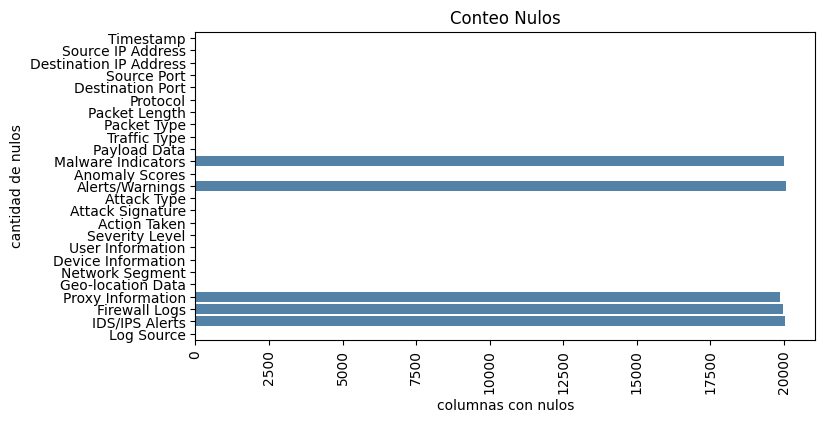

In [30]:

nulos = df.isnull().sum()

plt.figure(figsize=(8,4))
sns.barplot(x=nulos.values, y=nulos.index, color="steelblue")
plt.title("Conteo Nulos")
plt.xlabel("columnas con nulos")
plt.ylabel("cantidad de nulos")
plt.xticks(rotation=90)

plt.show()

In [31]:
# Cambio de nulos por valores que permiten mas analisis
df["Malware Indicators"] = df["Malware Indicators"].fillna("no malware")
df["Alerts/Warnings"] = df["Alerts/Warnings"].fillna("no alert")
df["Proxy Information"] = df["Proxy Information"].fillna("no proxy")
df["Firewall Logs"] = df["Firewall Logs"].fillna("no firewall")
df["IDS/IPS Alerts"] = df["IDS/IPS Alerts"].fillna("no IDS/IPS alerts")


In [32]:
df.isnull().sum()

Timestamp                 0
Source IP Address         0
Destination IP Address    0
Source Port               0
Destination Port          0
Protocol                  0
Packet Length             0
Packet Type               0
Traffic Type              0
Payload Data              0
Malware Indicators        0
Anomaly Scores            0
Alerts/Warnings           0
Attack Type               0
Attack Signature          0
Action Taken              0
Severity Level            0
User Information          0
Device Information        0
Network Segment           0
Geo-location Data         0
Proxy Information         0
Firewall Logs             0
IDS/IPS Alerts            0
Log Source                0
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      40000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         40000 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [34]:
# Verificación de Timestamp
nat_count = df["Timestamp"].isnull().sum()
print(f"Timestamps inválidos: {nat_count}")

# errors="coerce" en la conversión
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

Timestamps inválidos: 0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Timestamp               40000 non-null  datetime64[ns]
 1   Source IP Address       40000 non-null  object        
 2   Destination IP Address  40000 non-null  object        
 3   Source Port             40000 non-null  int64         
 4   Destination Port        40000 non-null  int64         
 5   Protocol                40000 non-null  object        
 6   Packet Length           40000 non-null  int64         
 7   Packet Type             40000 non-null  object        
 8   Traffic Type            40000 non-null  object        
 9   Payload Data            40000 non-null  object        
 10  Malware Indicators      40000 non-null  object        
 11  Anomaly Scores          40000 non-null  float64       
 12  Alerts/Warnings         40000 non-null  object

In [36]:
# Cambio de tipo de dato y creacion de columnas
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["Hour"] = df["Timestamp"].dt.hour

df["DayOfWeekName"] = df["Timestamp"].dt.day_name()
df["DayOfWeekNumber"] = df["Timestamp"].dt.day_of_week
df["Date"] = df["Timestamp"].dt.date

In [37]:
df[["Timestamp","Date","DayOfWeekName","DayOfWeekNumber","Day"]].head()

,Timestamp,Date,DayOfWeekName,DayOfWeekNumber,Day
0,2023-05-30 06:33:58,2023-05-30,Tuesday,1,30
1,2020-08-26 07:08:30,2020-08-26,Wednesday,2,26
2,2022-11-13 08:23:25,2022-11-13,Sunday,6,13
3,2023-07-02 10:38:46,2023-07-02,Sunday,6,2
4,2023-07-16 13:11:07,2023-07-16,Sunday,6,16


In [38]:
# Hora del día categorizada
df["time_of_day"] = pd.cut(df["Hour"], 
    bins=[-1, 6, 12, 18, 24], 
    labels=["dawn", "morning", "afternoon", "night"])

# Año y mes juntos para timeline
df["year_month"] = df["Timestamp"].dt.to_period("M").astype(str)

# Categorizar anomaly scores
df["risk_category"] = pd.cut(df["Anomaly Scores"],
    bins=[-1, 33, 66, 100],
    labels=["low", "medium", "high"])

In [39]:
df[["time_of_day","year_month","risk_category"]].head()

,time_of_day,year_month,risk_category
0,dawn,2023-05,low
1,morning,2020-08,medium
2,morning,2022-11,high
3,morning,2023-07,low
4,afternoon,2023-07,low


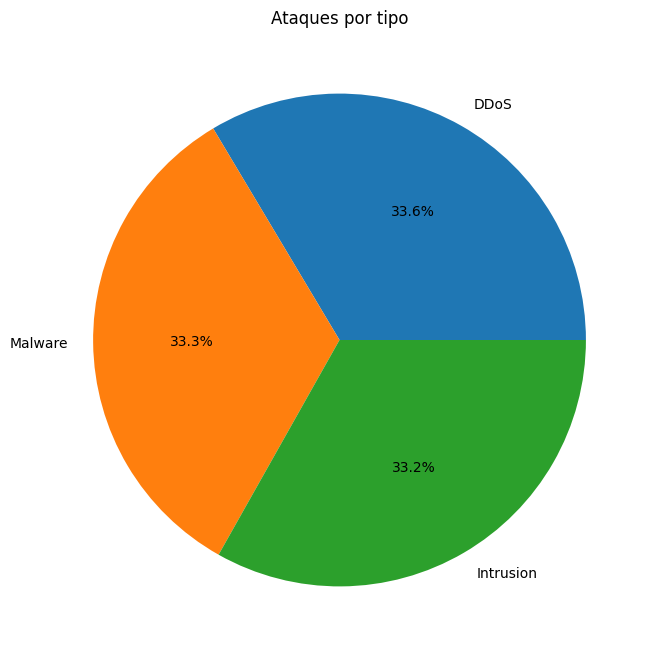

In [40]:
# 1. Ataques por tipo 
conteo = df["Attack Type"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(conteo.values, labels=conteo.index, autopct="%1.1f%%")
plt.title("Ataques por tipo")
plt.show()

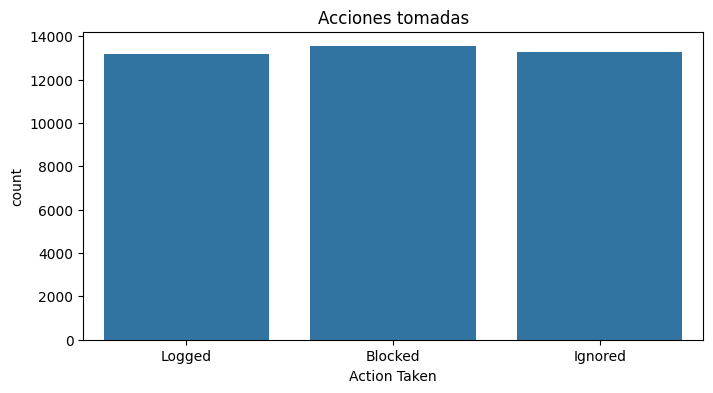

In [41]:
# 2. Acciones tomadas 
plt.figure(figsize=(8,4))
sns.countplot(x="Action Taken", data=df )
plt.title("Acciones tomadas")
plt.show()

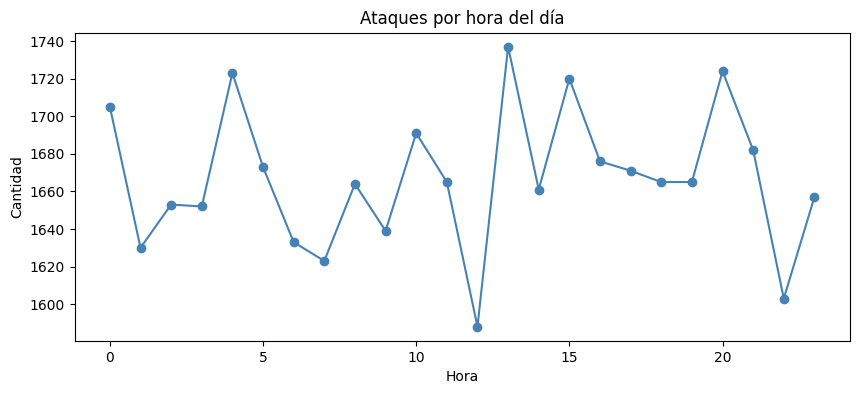

In [42]:
# 3. Ataques por hora 
plt.figure(figsize=(10,4))
df.groupby("Hour").size().plot(kind="line", marker="o", color="steelblue")
plt.title("Ataques por hora del día")
plt.xlabel("Hora")
plt.ylabel("Cantidad")
plt.show()

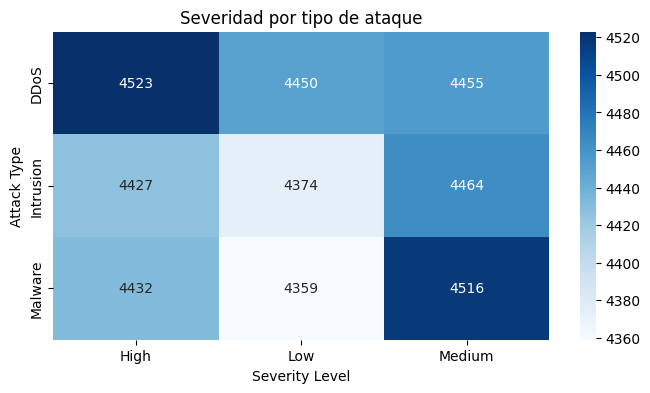

In [43]:
# 4. Severidad vs tipo de ataque 
plt.figure(figsize=(8,4))
tabla = pd.crosstab(df["Attack Type"], df["Severity Level"])
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Severidad por tipo de ataque")
plt.show()

In [44]:
print("Duplicados: ",df.duplicated().sum())

Duplicados:  0


In [45]:
df.head(10)

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Year,Month,Day,Hour,DayOfWeekName,DayOfWeekNumber,Date,time_of_day,year_month,risk_category
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,2023,5,30,6,Tuesday,1,2023-05-30,dawn,2023-05,low
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,2020,8,26,7,Wednesday,2,2020-08-26,morning,2020-08,medium
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,2022,11,13,8,Sunday,6,2022-11-13,morning,2022-11,high
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,2023,7,2,10,Sunday,6,2023-07-02,morning,2023-07,low
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,2023,7,16,13,Sunday,6,2023-07-16,afternoon,2023-07,low
5,2022-10-28 13:14:27,198.102.5.160,147.190.155.133,17430,52805,UDP,1423,Data,HTTP,Repellat quas illum harum fugit incidunt exerc...,...,2022,10,28,13,Friday,4,2022-10-28,afternoon,2022-10,low
6,2022-05-16 17:55:43,97.253.103.59,77.16.101.53,26562,17416,TCP,379,Data,DNS,Qui numquam inventore repellat ratione fugit o...,...,2022,5,16,17,Monday,0,2022-05-16,afternoon,2022-05,low
7,2023-02-12 07:13:17,11.48.99.245,178.157.14.116,34489,20396,ICMP,1022,Data,DNS,Amet libero optio quidem praesentium libero. E...,...,2023,2,12,7,Sunday,6,2023-02-12,morning,2023-02,medium
8,2023-06-27 11:02:56,49.32.208.167,72.202.237.9,56296,20857,TCP,1281,Control,FTP,Veritatis nihil amet atque molestias aperiam m...,...,2023,6,27,11,Tuesday,1,2023-06-27,morning,2023-06,medium
9,2021-08-15 22:29:04,114.109.149.113,160.88.194.172,37918,50039,UDP,224,Data,HTTP,Consequatur ipsum autem reprehenderit quae. Do...,...,2021,8,15,22,Sunday,6,2021-08-15,night,2021-08,low


In [46]:

df["year_month"].head()

0    2023-05
1    2020-08
2    2022-11
3    2023-07
4    2023-07
Name: year_month, dtype: object

In [47]:
# Crear conexión al DB limpio
engine = create_engine("sqlite:///../output/cybersecurity_clean.db")

In [48]:
# Guardar dataframe limpio en la base de datos
df.to_sql(
    "cybersecurity_attacks",
    con=engine,
    if_exists="replace",
    index=False
)

print("Base de datos limpia guardada correctamente")


Base de datos limpia guardada correctamente


In [49]:
print(df["Anomaly Scores"].head(5))
df.to_csv("../output/cybersecurity_clean.csv", index=False, float_format="%.2f")
print("✓ CSV reexportado correctamente")

0    28.67
1    51.50
2    87.42
3    15.79
4     0.52
Name: Anomaly Scores, dtype: float64
✓ CSV reexportado correctamente
